In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Loading the dataset
df = pd.read_csv('flood_risk_ml_dataset.csv')

# Displaying the first few rows of the dataset
df.head()

,county,nearest_town,town_size,landcover_types,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score,risk_category
0,Migori,Mohoni,Town,waterbodies,1134.0,14191.648756,9.891734e+06,0.0,9.0,0,0.0,2.2,Low
1,Migori,Mohoni,Town,waterbodies,1134.0,16419.789667,9.898062e+06,0.0,9.0,0,0.0,2.2,Low
2,Migori,Nyatembe,Town,waterbodies,1134.0,18365.752928,9.904390e+06,0.0,9.0,0,0.0,2.2,Low
3,Migori,Nyandhiwa,Town,waterbodies,1134.0,13839.292053,9.910718e+06,0.0,9.0,0,0.0,2.2,Low
4,Homa Bay,Nyandhiwa,Town,waterbodies,1134.0,10562.446388,9.917045e+06,0.0,9.0,0,0.0,2.2,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14497 entries, 0 to 14496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   county                14497 non-null  object 
 1   nearest_town          14497 non-null  object 
 2   town_size             14497 non-null  object 
 3   landcover_types       14497 non-null  object 
 4   elevation_m           14497 non-null  float64
 5   dist_to_town_m        14497 non-null  float64
 6   dist_to_water_m       14497 non-null  float64
 7   topographic_hazard    14497 non-null  float64
 8   landcover_risk        14497 non-null  float64
 9   water_proximity_risk  14497 non-null  int64  
 10  vulnerability_score   14497 non-null  float64
 11  flood_risk_score      14497 non-null  float64
 12  risk_category         14497 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 1.4+ MB


In [4]:
df.describe()

,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score
count,14497.000000,14497.000000,1.449700e+04,14497.000000,14497.000000,14497.0,14497.000000,14497.000000
mean,789.020418,23644.471462,1.006839e+07,1.242533,2.449127,0.0,0.736256,1.133828
std,639.259044,18524.531991,2.411687e+05,1.811884,2.715400,0.0,1.429902,0.903307
min,0.000000,95.957988,9.500881e+06,0.000000,0.000000,0.0,0.000000,0.000000
25%,320.000000,8753.448820,9.880211e+06,0.000000,1.000000,0.0,0.000000,0.600000
50%,589.000000,18880.673867,1.006472e+07,0.000000,1.000000,0.0,0.000000,0.800000
75%,1139.000000,34186.940785,1.027426e+07,2.000000,3.000000,0.0,1.500000,1.400000
max,4413.000000,97465.659444,1.051292e+07,10.000000,10.000000,0.0,10.000000,6.200000


In [5]:
df.isnull().sum()

county                  0
nearest_town            0
town_size               0
landcover_types         0
elevation_m             0
dist_to_town_m          0
dist_to_water_m         0
topographic_hazard      0
landcover_risk          0
water_proximity_risk    0
vulnerability_score     0
flood_risk_score        0
risk_category           0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
counties = df['county'].nunique()
print(counties)

nearest_town = df['nearest_town'].nunique()
print(nearest_town)

town_size = df['town_size'].nunique()
print(town_size)

land_cover = df['landcover_types'].nunique()
print(land_cover)

risk = df['risk_category'].nunique()
print(risk)

47
1343
2
35
3


In [8]:
df['town_size'].value_counts()

town_size
Town          14481
Major City       16
Name: count, dtype: int64

In [9]:
# Filter to show only Major Cities
major_cities_df = df[df['town_size'] == 'Major City']

# Display the 16 major cities
print("The 16 Major Cities are:")
print(major_cities_df)

The 16 Major Cities are:
            county nearest_town   town_size            landcover_types  \
634         Kisumu       Kisumu  Major City                waterbodies   
711         Kisumu       Kisumu  Major City                urban_areas   
712         Kisumu       Kisumu  Major City                    unknown   
1599   Uasin Gishu      Eldoret  Major City                    unknown   
1600   Uasin Gishu      Eldoret  Major City                    forests   
3077        Nakuru       Nakuru  Major City                    unknown   
3192        Nakuru       Nakuru  Major City  protected_areas,rangeland   
3193        Nakuru       Nakuru  Major City                    forests   
3194        Nakuru       Nakuru  Major City                    forests   
5217        Kiambu        Thika  Major City                    unknown   
5340        Kiambu        Thika  Major City                    unknown   
5341        Kiambu        Thika  Major City                    forests   
5464        K

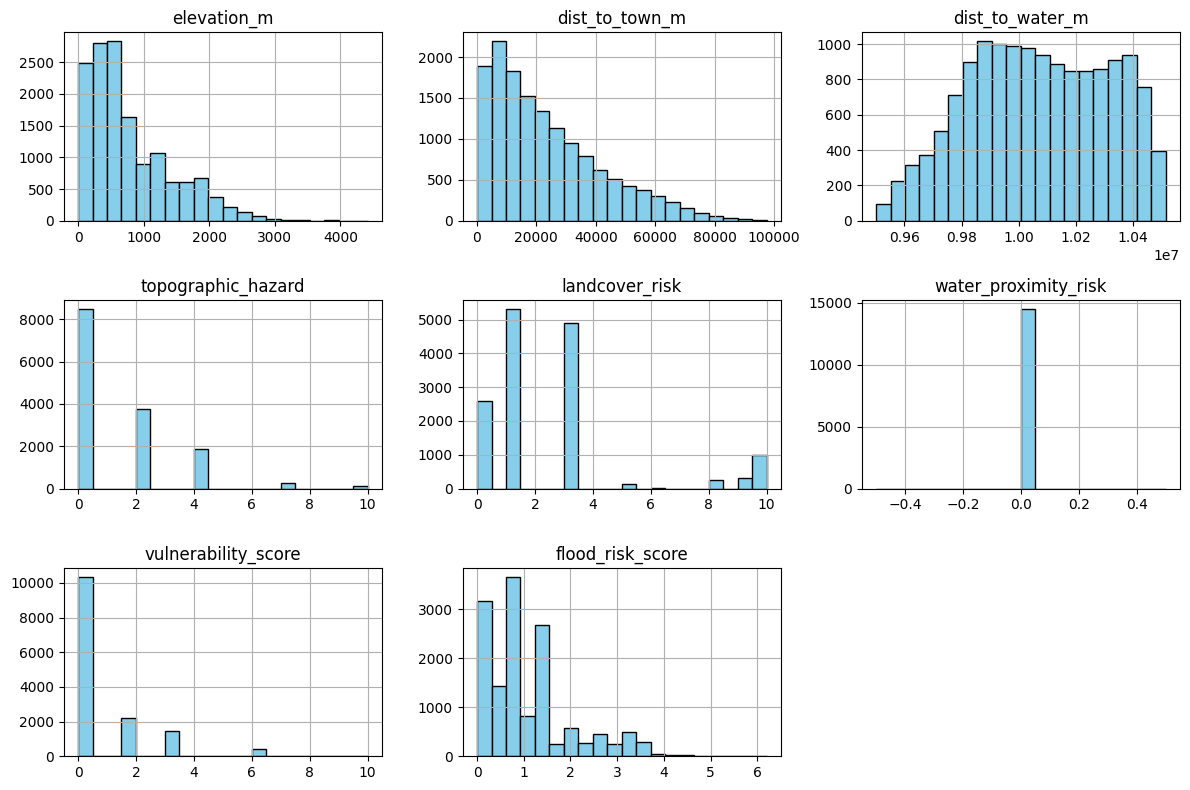

In [10]:
df.hist(figsize=(12, 8), bins=20, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

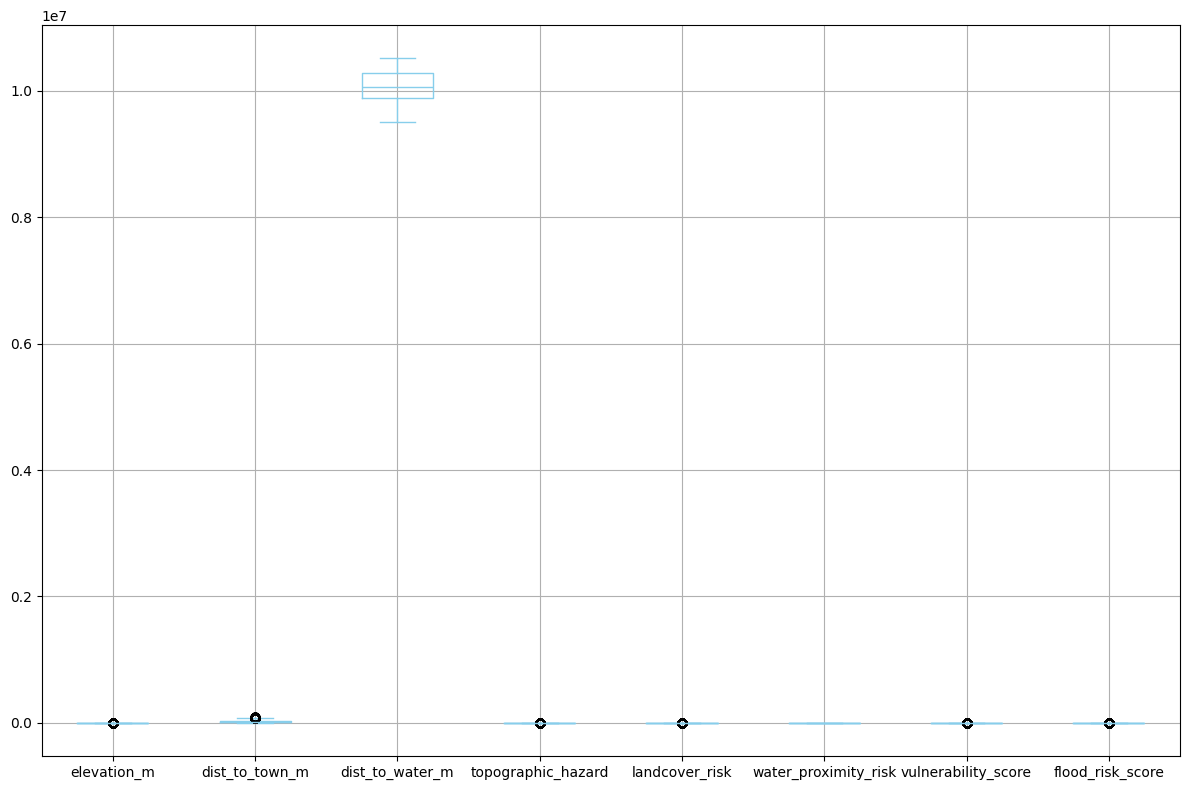

In [11]:
df.boxplot(figsize=(12, 8), color='skyblue')
plt.tight_layout()
plt.show()

In [12]:
df['landcover_types'].value_counts()

landcover_types
rangeland                                         4553
forests                                           4325
unknown                                           2589
forests,protected_areas                            835
floodplains,rangeland                              450
protected_areas,rangeland                          330
waterbodies                                        307
floodplains,forests                                294
protected_areas                                    151
rangeland,wetlands                                 150
bareareas                                          129
floodplains,rangeland,wetlands                     108
forests,wetlands                                    76
floodplains,forests,wetlands                        54
floodplains                                         35
urban_areas                                         20
wetlands                                            15
floodplains,forests,protected_areas              

In [13]:
df['landcover_types'].nunique()

35

In [14]:
df.columns

Index(['county', 'nearest_town', 'town_size', 'landcover_types', 'elevation_m',
       'dist_to_town_m', 'dist_to_water_m', 'topographic_hazard',
       'landcover_risk', 'water_proximity_risk', 'vulnerability_score',
       'flood_risk_score', 'risk_category'],
      dtype='object')